# Exploratory Data Analysis of Large-Scale Retail Transaction Data

### Using Univariate, Bivariate and Multivariate Statistical Techniques

## Project Overview

Exploratory Data Analysis (EDA) is a systematic process used to inspect, summarize,
visualize and understand a dataset before applying statistical or machine learning
models.

This project performs detailed exploratory data analysis on a large-scale retail
transaction dataset containing 100,000 records and 18 variables.

The analysis will focus on:

- Understanding the structure and characteristics of the dataset
- Identifying missing, duplicate and invalid values
- Performing data cleaning and preparation
- Conducting univariate, bivariate and multivariate analysis
- Detecting and interpreting outliers
- Measuring correlation between numerical variables
- Analyzing skewness and kurtosis
- Extracting meaningful business insights

### Tools and Libraries

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
#Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully.")

Libraries imported successfully.


### Loading and Intial Exploration of dataset

In [3]:
df = pd.read_csv("retail_large_dataset.csv")

In [4]:
# Showing the first five rows of the dataset 
df.head()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
0,C10000,56,Male,Hyderabad,Telangana,New,O50000,2025-05-10,Health,Protein Powder,38658,3,7,107855.82,Debit Card,Standard,5,No
1,C10001,36,Male,Pune,Maharashtra,Premium,O50001,2023-11-27,Electronics,Smartphone,22462,4,20,71878.40,Cash on Delivery,Standard,4,Yes
2,C10002,20,Male,Kolkata,West Bengal,New,O50002,2025-02-08,Fashion,Women Dress,56601,2,27,82637.46,Credit Card,Standard,5,No
3,C10003,39,Female,Jaipur,Rajasthan,New,O50003,2024-04-19,Beauty,Perfume,26158,3,9,71411.34,UPI,Standard,3,No
4,C10004,20,Male,Chennai,Tamil Nadu,Premium,O50004,2024-10-08,Beauty,Shampoo,31240,1,6,29365.60,UPI,Standard,2,No


In [5]:
# Showing the last five rows of the dataset
df.tail()

,customer_id,age,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,product_price,quantity,discount_percentage,final_price,payment_method,shipping_type,delivery_days,return_status
99995,C109995,29,Female,Pune,Maharashtra,Regular,O149995,2024-06-11,Health,Supplements,49293,1,11,43870.77,Debit Card,Standard,9,No
99996,C109996,28,Male,Mumbai,Maharashtra,Premium,O149996,2024-04-27,Fashion,Men T-Shirt,5722,2,22,8926.32,Cash on Delivery,Express,1,No
99997,C109997,44,Female,Jaipur,Rajasthan,Premium,O149997,2024-04-14,Grocery,Snacks,6311,4,11,22467.16,Cash on Delivery,Express,9,No
99998,C109998,45,Male,Jaipur,Rajasthan,Premium,O149998,2024-09-08,Beauty,Shampoo,46888,1,28,33759.36,Debit Card,Standard,1,No
99999,C109999,19,Male,Kolkata,West Bengal,New,O149999,2025-11-15,Health,Supplements,37361,3,3,108720.51,Credit Card,Standard,2,No


In [6]:
# Displaying the number of rows and columns explicitly
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

Number of rows    : 100,000
Number of columns : 18


In [7]:
# Showcasing column names in a reader friendly format
for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. customer_id
2. age
3. gender
4. city
5. state
6. customer_segment
7. order_id
8. order_date
9. product_category
10. product_subcategory
11. product_price
12. quantity
13. discount_percentage
14. final_price
15. payment_method
16. shipping_type
17. delivery_days
18. return_status


In [8]:
# Checking for essential information about dataset such as dtypes , non-null values , memory usage etc.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   customer_id          100000 non-null  object 
 1   age                  100000 non-null  int64  
 2   gender               100000 non-null  object 
 3   city                 100000 non-null  object 
 4   state                100000 non-null  object 
 5   customer_segment     100000 non-null  object 
 6   order_id             100000 non-null  object 
 7   order_date           100000 non-null  object 
 8   product_category     100000 non-null  object 
 9   product_subcategory  100000 non-null  object 
 10  product_price        100000 non-null  int64  
 11  quantity             100000 non-null  int64  
 12  discount_percentage  100000 non-null  int64  
 13  final_price          100000 non-null  float64
 14  payment_method       100000 non-null  object 
 15  shipping_type     

In [9]:
# Counting the number of columns based on their data types
df.dtypes.value_counts()

object     12
int64       5
float64     1
Name: count, dtype: int64

In [10]:
# Summarizing the dataset to get a statistical overview of numerical columns 
df.describe()

,age,product_price,quantity,discount_percentage,final_price,delivery_days
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,41.56,30164.53,2.50,15.01,64165.72,5.51
std,13.85,17139.68,1.12,8.95,49969.28,2.87
min,18.00,500.00,1.00,0.00,357.00,1.00
25%,30.00,15375.00,1.00,7.00,24705.00,3.00
50%,42.00,30148.00,3.00,15.00,49752.39,5.00
75%,54.00,44957.00,4.00,23.00,94046.07,8.00
max,65.00,59998.00,4.00,30.00,239980.00,10.00


In [11]:
# Summarizing the categorical columns to get statistical overview 
df.describe(include='object')

,customer_id,gender,city,state,customer_segment,order_id,order_date,product_category,product_subcategory,payment_method,shipping_type,return_status
count,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000,100000
unique,100000,2,10,9,3,100000,1095,6,21,4,2,2
top,C10000,Male,Hyderabad,Maharashtra,New,O50000,2023-04-12,Health,Protein Powder,Credit Card,Express,No
freq,1,50111,10150,19952,33488,1,124,16858,5668,25307,50008,85189


In [12]:
# Checking for number of unique values in each column
df.nunique()

customer_id            100000
age                        48
gender                      2
city                       10
state                       9
customer_segment            3
order_id               100000
order_date               1095
product_category            6
product_subcategory        21
product_price           48449
quantity                    4
discount_percentage        31
final_price             97092
payment_method              4
shipping_type               2
delivery_days              10
return_status               2
dtype: int64

In [13]:
categorical_columns = [
    'gender',
    'city',
    'state',
    'customer_segment',
    'product_category',
    'product_subcategory',
    'payment_method',
    'shipping_type',
    'return_status'
]

for column in categorical_columns:
    print(f"\n{column}")
    print(df[column].unique())


gender
['Male' 'Female']

city
['Hyderabad' 'Pune' 'Kolkata' 'Jaipur' 'Chennai' 'Delhi' 'Ahmedabad'
 'Noida' 'Mumbai' 'Bangalore']

state
['Telangana' 'Maharashtra' 'West Bengal' 'Rajasthan' 'Tamil Nadu' 'Delhi'
 'Gujarat' 'Uttar Pradesh' 'Karnataka']

customer_segment
['New' 'Premium' 'Regular']

product_category
['Health' 'Electronics' 'Fashion' 'Beauty' 'Grocery' 'Home & Kitchen']

product_subcategory
['Protein Powder' 'Smartphone' 'Women Dress' 'Perfume' 'Shampoo' 'Pulses'
 'Headphones' 'Vitamins' 'Blender' 'Supplements' 'Snacks' 'Shoes'
 'Organic Rice' 'Laptop' 'Face Cream' 'Vacuum Cleaner' 'Men T-Shirt'
 'Jeans' 'Tablet' 'Cookware' 'Microwave']

payment_method
['Debit Card' 'Cash on Delivery' 'Credit Card' 'UPI']

shipping_type
['Standard' 'Express']

return_status
['No' 'Yes']


In [14]:
# Checking the date column explicitly to see if it is in the correct format
df['order_date'].head()

0    2025-05-10
1    2023-11-27
2    2025-02-08
3    2024-04-19
4    2024-10-08
Name: order_date, dtype: object

## Column Classification

### Identifier Variables
- customer_id
- order_id

### Numerical Variables
- age
- product_price
- quantity
- discount_percentage
- final_price
- delivery_days

### Categorical Variables
- gender
- city
- state
- customer_segment
- product_category
- product_subcategory
- payment_method
- shipping_type
- return_status

### Date Variable
- order_date

## Initial Observations

Based on the initial inspection of the dataset:

1. The dataset contains 100,000 transaction records and 18 variables.
2. The dataset includes identifier, numerical, categorical and date variables.
3. Customer and order identifiers should not be treated as conventional numerical features.
4. The numerical variables include age, product price, quantity, discount percentage,
   final price and delivery days.
5. The dataset contains categorical information related to customers, products,
   payment methods, shipping and returns.
6. The order date provides an opportunity for time-based analysis.
7. Further investigation is required to identify missing, duplicate, inconsistent
   and invalid values before performing detailed visualization.

# 1. Data Quality Assessment

## 1.1 Missing Value Analysis

The dataset was checked for missing values across all 18 columns. The initial
inspection showed that every column contains 100,000 non-null records. A final
aggregate check is performed below to confirm whether any missing values are
present.

In [15]:
# Checking total missing values in the dataset
total_missing = df.isnull().sum().sum()

print(f"Total missing values in the dataset: {total_missing}")

Total missing values in the dataset: 0


### Observation

No missing values were detected in the dataset. Therefore, no missing-value
imputation or row removal is required at this stage.

## 1.2 Duplicate Record Analysis

Duplicate records can cause transactions to be counted more than once and may
distort statistical summaries and visualizations. Therefore, the dataset is
checked for completely duplicated rows.

In [16]:
# Checking for completely duplicated rows
duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count}")

Duplicate rows: 0


### Observation

No completely duplicated records were found in the dataset. Therefore, no rows
need to be removed on the basis of full-row duplication.

## 1.3 Categorical Value Validation

In [17]:
# Checking the frequency of values in each categorical column
for column in categorical_columns:
    print(df[column].value_counts(dropna=False))

gender
Male      50111
Female    49889
Name: count, dtype: int64
city
Hyderabad    10150
Ahmedabad    10057
Bangalore    10047
Mumbai       10015
Chennai       9993
Noida         9964
Delhi         9962
Kolkata       9955
Pune          9937
Jaipur        9920
Name: count, dtype: int64
state
Maharashtra      19952
Telangana        10150
Gujarat          10057
Karnataka        10047
Tamil Nadu        9993
Uttar Pradesh     9964
Delhi             9962
West Bengal       9955
Rajasthan         9920
Name: count, dtype: int64
customer_segment
New        33488
Regular    33361
Premium    33151
Name: count, dtype: int64
product_category
Health            16858
Home & Kitchen    16848
Fashion           16613
Grocery           16592
Electronics       16576
Beauty            16513
Name: count, dtype: int64
product_subcategory
Protein Powder    5668
Supplements       5657
Shampoo           5578
Organic Rice      5567
Snacks            5548
Vitamins          5533
Face Cream        5512
Pulses       

In [18]:
# Checking for leading or trailing whitespace in categorical values
whitespace_issues = {}

for column in categorical_columns:
    count = (
        df[column].astype(str)
        .str.strip()
        .ne(df[column].astype(str))
        .sum()
    )
    whitespace_issues[column] = count

pd.Series(whitespace_issues, name='Whitespace Issues')

gender                 0
city                   0
state                  0
customer_segment       0
product_category       0
product_subcategory    0
payment_method         0
shipping_type          0
return_status          0
Name: Whitespace Issues, dtype: int64

### Observation

The categorical variables contain consistent and expected category labels.
No unexpected categories or obvious formatting inconsistencies were identified
during the initial validation. The whitespace check will be used to confirm that
categorical values do not contain leading or trailing spaces.

No categorical-value cleaning is required based on the current validation.

## 1.4 Numerical Value Validation

Numerical variables are examined for logically invalid values based on their
expected meaning and the observed structure of the dataset. The validation
focuses on age, product price, quantity, discount percentage, final price and
delivery days.

The objective is to distinguish genuinely invalid values from legitimate
extreme observations, which will be analyzed separately during outlier analysis.

In [19]:
# Defining the numerical columns

numerical_columns = [
    'age',
    'product_price',
    'quantity',
    'discount_percentage',
    'final_price',
    'delivery_days'
]


In [20]:
# Creating a consolidated validation summary for numerical variables

numerical_validation = pd.DataFrame({
    'Column': numerical_columns,
    'Minimum': [df[col].min() for col in numerical_columns],
    'Maximum': [df[col].max() for col in numerical_columns],
    'Zero Count': [(df[col] == 0).sum() for col in numerical_columns],
    'Negative Count': [(df[col] < 0).sum() for col in numerical_columns]
})

numerical_validation

,Column,Minimum,Maximum,Zero Count,Negative Count
0,age,18.00,65.00,0,0
1,product_price,500.00,59998.00,0,0
2,quantity,1.00,4.00,0,0
3,discount_percentage,0.00,30.00,3300,0
4,final_price,357.00,239980.00,0,0
5,delivery_days,1.00,10.00,0,0


In [21]:
# Counting logically invalid values for each numerical variable

invalid_numeric_counts = {
    'Invalid Age (< 18)': (df['age'] < 18).sum(),
    'Invalid Product Price (<= 0)': (df['product_price'] <= 0).sum(),
    'Invalid Quantity (<= 0)': (df['quantity'] <= 0).sum(),
    'Invalid Discount (< 0 or > 100)': (
        (df['discount_percentage'] < 0) |
        (df['discount_percentage'] > 100)
    ).sum(),
    'Invalid Final Price (<= 0)': (df['final_price'] <= 0).sum(),
    'Invalid Delivery Days (<= 0)': (df['delivery_days'] <= 0).sum()
}

pd.Series(invalid_numeric_counts, name='Invalid Records')

Invalid Age (< 18)                 0
Invalid Product Price (<= 0)       0
Invalid Quantity (<= 0)            0
Invalid Discount (< 0 or > 100)    0
Invalid Final Price (<= 0)         0
Invalid Delivery Days (<= 0)       0
Name: Invalid Records, dtype: int64

In [22]:
# Checking whether discounts fall outside the expected 0-30% range
outside_discount_range = df[
    (df['discount_percentage'] < 0) |
    (df['discount_percentage'] > 30)
]

print(f"Records outside the 0-30% discount range: {len(outside_discount_range)}")

Records outside the 0-30% discount range: 0


### Observation

The numerical variables do not contain any logically invalid values based on the
validation rules applied. Age values fall within the observed range of 18–65,
product prices and final prices are positive, quantities range from 1–4, and
delivery times range from 1–10 days.

Discount percentages fall entirely within the 0–30% range, with 3,300 records
having a valid discount of 0%. These records represent transactions where no
discount was applied and therefore do not require removal.

No numerical-value cleaning is required based on the current validation.
Potential extreme observations will be investigated separately during outlier
analysis.

## 1.5 Date Validation

The `order_date` column is currently stored as an object datatype. Before
converting it to datetime, the values are checked for invalid or unparseable
dates and the overall date range is examined.

In [23]:
# Attempting to parse order_date values as datetime
parsed_dates = pd.to_datetime(df['order_date'], errors='coerce')

invalid_date_count = parsed_dates.isna().sum()

print(f"Invalid date values: {invalid_date_count}")

Invalid date values: 0


In [24]:
# Checking the date range
print(f"Earliest order date: {parsed_dates.min()}")
print(f"Latest order date  : {parsed_dates.max()}")

Earliest order date: 2023-01-01 00:00:00
Latest order date  : 2025-12-30 00:00:00


In [25]:
print(f"Unique order dates: {parsed_dates.nunique()}")

Unique order dates: 1095


### Date Continuity Check

In addition to validating individual date values, the order-date range is
checked for missing calendar dates. This helps determine whether the dataset
contains any gaps in its daily timeline.

In [26]:
# Checking whether any calendar dates are missing from the observed date range

expected_dates = pd.date_range(
    start=parsed_dates.min(),
    end=parsed_dates.max(),
    freq='D'
)

missing_dates = expected_dates.difference(parsed_dates)

print(f"Missing calendar dates: {len(missing_dates)}")

Missing calendar dates: 0


### Observation

All values in `order_date` were successfully parsed, with no invalid or
unparseable dates detected. The dataset contains 1,095 unique order dates
between 1 January 2023 and 30 December 2025.

The date range will later be converted to datetime format and used for
time-based exploratory analysis such as monthly, weekly and daily transaction
patterns.

## 1.6 Business-Rule Validation

In addition to checking individual fields, related numerical variables are
validated against an expected pricing relationship. The calculated final price
is compared with the recorded `final_price` to identify potentially inconsistent
transactions.

The expected relationship is:

Expected Final Price = Product Price × Quantity × (1 − Discount Percentage / 100)

This validation is exploratory because the dataset documentation does not
specify whether additional charges, taxes, shipping costs or other pricing
adjustments are included in `final_price`.

In [27]:
# Calculating the expected final price using the observed pricing components

expected_final_price = (
    df['product_price']
    * df['quantity']
    * (1 - df['discount_percentage'] / 100)
)

In [28]:
# Measuring the difference between recorded and expected final price

price_difference = df['final_price'] - expected_final_price

price_difference.describe()

count   100000.00
mean         0.00
std          0.00
min         -0.00
25%          0.00
50%          0.00
75%          0.00
max          0.00
dtype: float64

In [29]:
# Checking how many transactions closely match the expected pricing formula

tolerance = 1

matching_records = price_difference.abs() <= tolerance

print(f"Matching records: {matching_records.sum():,}")
print(f"Non-matching records: {(~matching_records).sum():,}")
print(f"Match percentage: {matching_records.mean() * 100:.2f}%")

Matching records: 100,000
Non-matching records: 0
Match percentage: 100.00%


### Observation

The recorded `final_price` is fully consistent with the expected pricing
calculation derived from `product_price`, `quantity` and `discount_percentage`.
All 100,000 transactions match the expected calculation within the defined
tolerance, resulting in a 100.00% consistency rate.

Therefore, no pricing inconsistencies were identified and no corrections to
these monetary variables are required based on this validation.

## 1.7 Data Quality Summary

The dataset underwent a systematic quality assessment covering missing values,
duplicate records, categorical consistency, numerical validity, date validity
and internal pricing consistency.

The analysis found no missing values, complete duplicate records, categorical
formatting issues or logically invalid numerical values. All order dates were
valid and the observed date range contained no missing calendar dates.

Furthermore, the recorded `final_price` was found to be fully consistent with
the expected price calculated from product price, quantity and discount
percentage.

Based on these checks, the dataset is considered suitable for exploratory
visualization without requiring row deletion or value-level correction.
The `order_date` column will be converted to datetime format during the
data-preparation stage.

# 2. Data Preparation & Feature Creation

The dataset passed the data-quality assessment without requiring value-level
correction or row removal. The preparation stage therefore focuses on converting
the date field into an appropriate datetime format and creating derived
time-based variables that will support subsequent exploratory analysis.

In [30]:
# Creating a working copy for EDA preparation
df_eda = df.copy()

In [31]:
# Converting order_date from object to datetime
df_eda['order_date'] = pd.to_datetime(df_eda['order_date'])

In [32]:
# Confirming the new datatype
print(f"order_date datatype: {df_eda['order_date'].dtype}")

order_date datatype: datetime64[ns]


In [33]:
df_eda['order_year'] = df_eda['order_date'].dt.year

In [34]:
df_eda['order_month'] = df_eda['order_date'].dt.month

In [35]:
df_eda['order_month_name'] = df_eda['order_date'].dt.month_name()

In [36]:
df_eda['order_quarter'] = df_eda['order_date'].dt.quarter

In [37]:
df_eda['order_day_of_week'] = df_eda['order_date'].dt.dayofweek

In [38]:
df_eda['order_day_name'] = df_eda['order_date'].dt.day_name()

In [39]:
df_eda['order_year_month'] = df_eda['order_date'].dt.to_period('M')

In [40]:
df_eda[
    [
        'order_date',
        'order_year',
        'order_month',
        'order_month_name',
        'order_quarter',
        'order_day_of_week',
        'order_day_name',
        'order_year_month'
    ]
].head()

,order_date,order_year,order_month,order_month_name,order_quarter,order_day_of_week,order_day_name,order_year_month
0,2025-05-10,2025,5,May,2,5,Saturday,2025-05
1,2023-11-27,2023,11,November,4,0,Monday,2023-11
2,2025-02-08,2025,2,February,1,5,Saturday,2025-02
3,2024-04-19,2024,4,April,2,4,Friday,2024-04
4,2024-10-08,2024,10,October,4,1,Tuesday,2024-10


In [41]:
# Checking the ranges and unique values of the derived time features

print(f"Years           : {sorted(df_eda['order_year'].unique())}")
print(f"Months          : {df_eda['order_month'].min()} - {df_eda['order_month'].max()}")
print(f"Quarters        : {sorted(df_eda['order_quarter'].unique())}")
print(f"Days of week    : {sorted(df_eda['order_day_of_week'].unique())}")
print(f"Unique months   : {df_eda['order_year_month'].nunique()}")

Years           : [np.int32(2023), np.int32(2024), np.int32(2025)]
Months          : 1 - 12
Quarters        : [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Days of week    : [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
Unique months   : 36


In [42]:
print(f"Original shape  : {df.shape}")
print(f"Prepared shape  : {df_eda.shape}")

Original shape  : (100000, 18)
Prepared shape  : (100000, 25)


### Observation

The validated retail transaction dataset was prepared for exploratory analysis
without altering the underlying transaction records.

The `order_date` column was converted from object to datetime format, and
additional time-based variables were derived to support temporal analysis.

The preparation process preserved all 100,000 records while expanding the dataset
from 18 to 25 columns through the addition of year, month, quarter, weekday and
year-month features.

The resulting dataset is now ready for detailed univariate, bivariate and
multivariate exploratory analysis.

# 3. Univariate Analysis

Univariate analysis examines one variable at a time to understand its
distribution, central tendency, variability and unusual characteristics.

The numerical variables are analyzed using descriptive statistics,
distribution plots and outlier-oriented visualizations.

## 3.1 Numerical Variable Analysis

In [43]:
numerical_columns = [
    'age',
    'product_price',
    'quantity',
    'discount_percentage',
    'final_price',
    'delivery_days'
]

In [44]:
# Generating a comprehensive statistical summary for numerical variables

numerical_stats = pd.DataFrame({
    'Mean': df_eda[numerical_columns].mean(),
    'Median': df_eda[numerical_columns].median(),
    'Std Dev': df_eda[numerical_columns].std(),
    'Minimum': df_eda[numerical_columns].min(),
    'Maximum': df_eda[numerical_columns].max(),
    'Skewness': df_eda[numerical_columns].skew(),
    'Kurtosis': df_eda[numerical_columns].kurtosis()
})

numerical_stats.round(2)

,Mean,Median,Std Dev,Minimum,Maximum,Skewness,Kurtosis
age,41.56,42.00,13.85,18.00,65.00,-0.00,-1.20
product_price,30164.53,30148.00,17139.68,500.00,59998.00,0.00,-1.20
quantity,2.50,3.00,1.12,1.00,4.00,-0.00,-1.36
discount_percentage,15.01,15.00,8.95,0.00,30.00,-0.00,-1.20
final_price,64165.72,49752.39,49969.28,357.00,239980.00,0.93,0.17
delivery_days,5.51,5.00,2.87,1.00,10.00,0.00,-1.22


## 3.2 Age Distribution

Age is analyzed as a numerical variable to understand its central tendency,
spread and distribution across the retail transaction dataset.

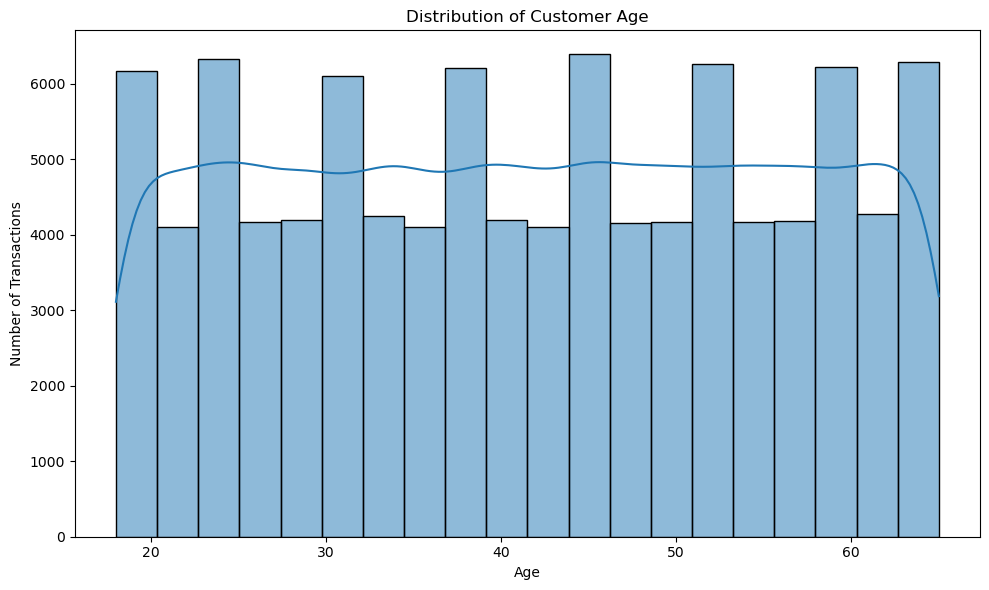

In [45]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x='age',
    bins=20,
    kde=True
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

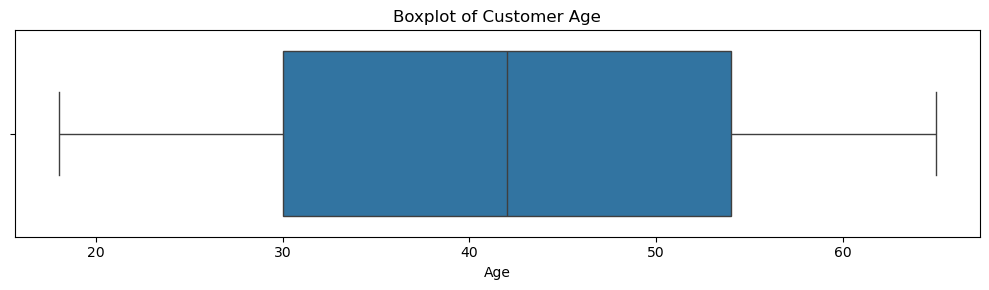

In [46]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df_eda,
    x='age'
)

plt.title('Boxplot of Customer Age')
plt.xlabel('Age')
plt.tight_layout()
plt.show()

### Age — Observation

The age distribution is relatively even across the observed range of 18 to 65
years, with no strong concentration around a particular age group. The mean
(41.56 years) and median (42 years) are very close, while the near-zero
skewness indicates an approximately symmetric distribution.

The boxplot shows a broad but balanced spread of ages, with no prominent
outlier observations visible.

### Interpretation

The customer base represented in the dataset is broadly distributed across
the observed adult age range rather than being concentrated within a narrow
age group. Since no substantial skewness or extreme observations are apparent,
age can be treated as a relatively stable demographic variable for subsequent
bivariate and multivariate analysis.

## 3.3 Product Price

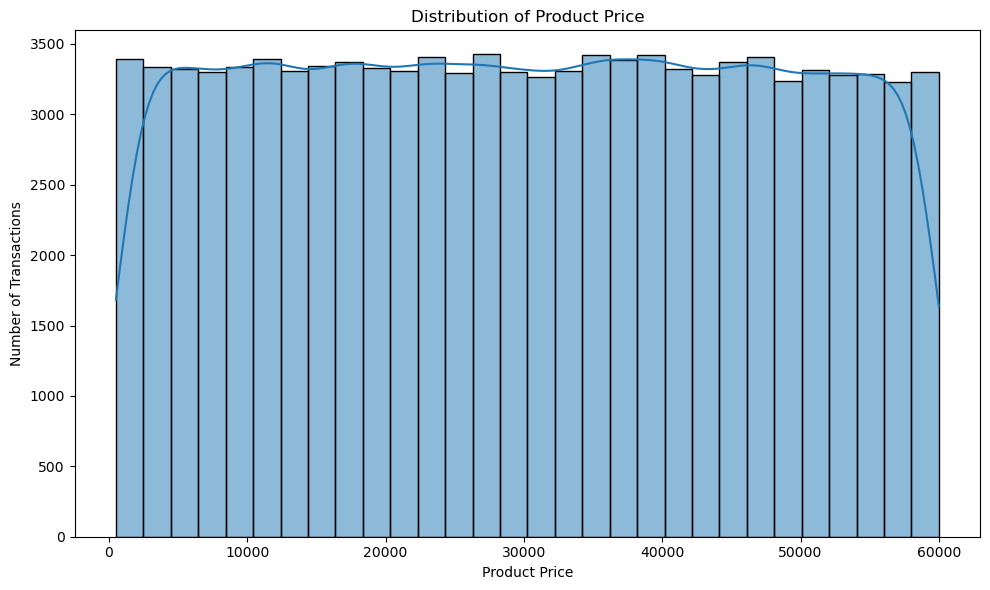

In [47]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x='product_price',
    bins=30,
    kde=True
)

plt.title('Distribution of Product Price')
plt.xlabel('Product Price')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

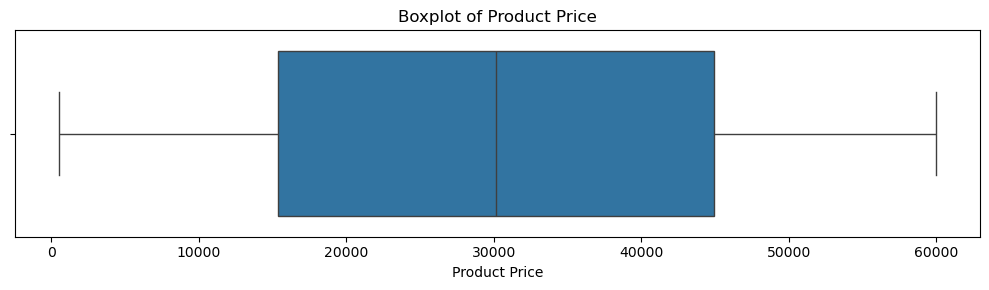

In [48]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df_eda,
    x='product_price'
)

plt.title('Boxplot of Product Price')
plt.xlabel('Product Price')
plt.tight_layout()
plt.show()

### Product Price — Observation

The product price distribution is broadly spread across the observed range of
₹500 to approximately ₹60,000. The histogram and KDE show a relatively even
distribution without a pronounced concentration toward either end.

The mean (₹30,164.53) and median (₹30,148) are almost identical, while the
skewness is approximately zero, indicating an approximately symmetric
distribution.

The boxplot shows a wide interquartile range with no prominent observations
outside the whiskers.

### Interpretation

Product prices are distributed relatively evenly across the observed price
range. Unlike the positive skew described as an example in the project
specification, the actual dataset does not show substantial skewness in
`product_price`.

The variable does not currently show strong evidence of extreme isolated
observations, although formal outlier detection will be performed separately.

## 3.4 Quantity Analysis

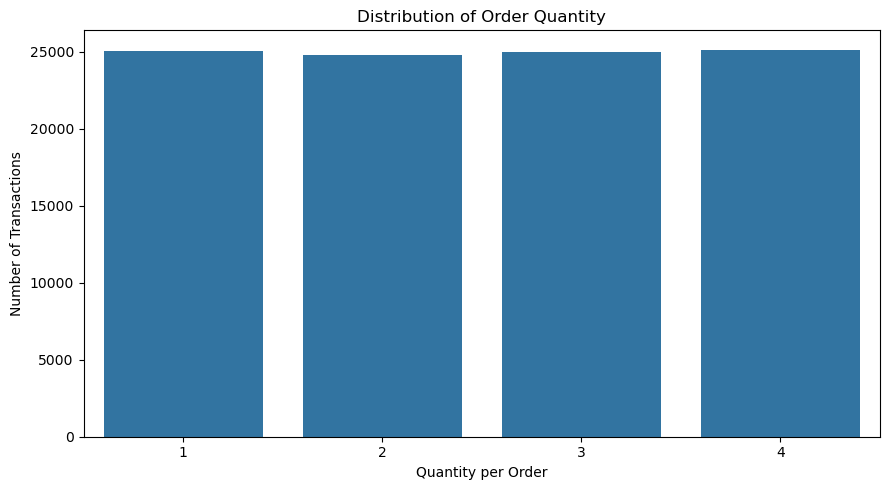

In [49]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df_eda,
    x='quantity'
)

plt.title('Distribution of Order Quantity')
plt.xlabel('Quantity per Order')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Quantity — Observation

The order quantity variable contains four possible values: 1, 2, 3 and 4.
The frequency distribution shows that these quantities occur at broadly similar
rates, with no single quantity dominating the dataset.

The mean quantity is 2.50 and the median is 3, while the near-zero skewness
indicates that the distribution is approximately balanced.

### Interpretation

Customer orders are fairly evenly distributed across the four available
quantity levels. This suggests that the dataset does not have a strong tendency
toward either very small or very large quantities.

## 3.5 Discount Percentage 

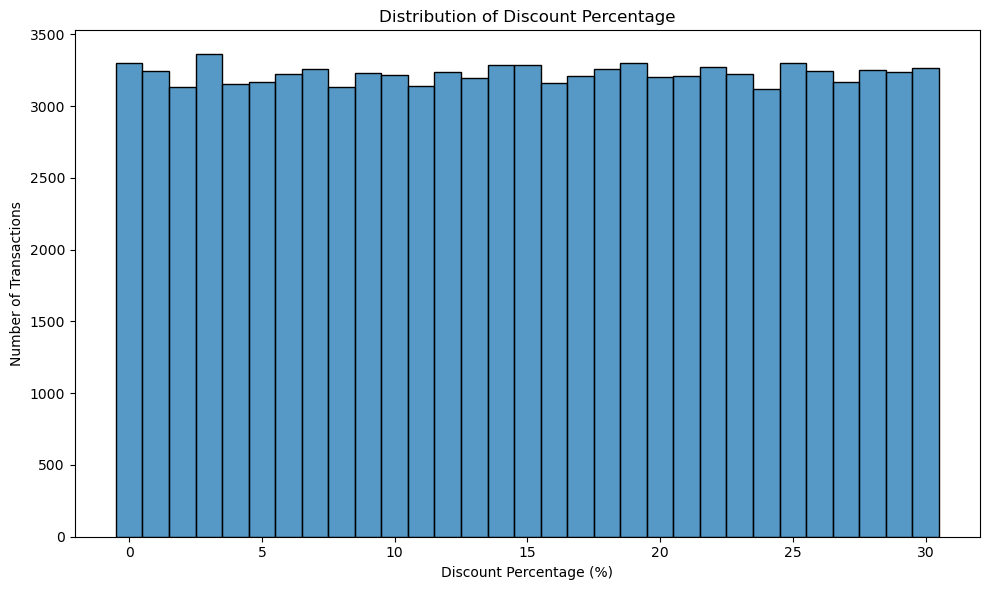

In [50]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x='discount_percentage',
    discrete=True
)

plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount Percentage (%)')
plt.ylabel('Number of Transactions')
plt.xticks(range(0, 31, 5))
plt.tight_layout()
plt.show()

### Discount Percentage — Observation

The discount percentage is distributed relatively evenly across the observed
range of 0% to 30%. No individual discount level dominates the distribution,
indicating an approximately uniform pattern.

The mean discount is 15.01%, while the median is 15%, and the skewness is
approximately zero, supporting the visual observation of a balanced
distribution.

### Interpretation

Discounts are broadly distributed across the full 0–30% range rather than
being concentrated around a small number of discount levels. The presence of
3,300 transactions with a 0% discount indicates that a portion of purchases
were made without a discount.

## 3.6 Final Price 


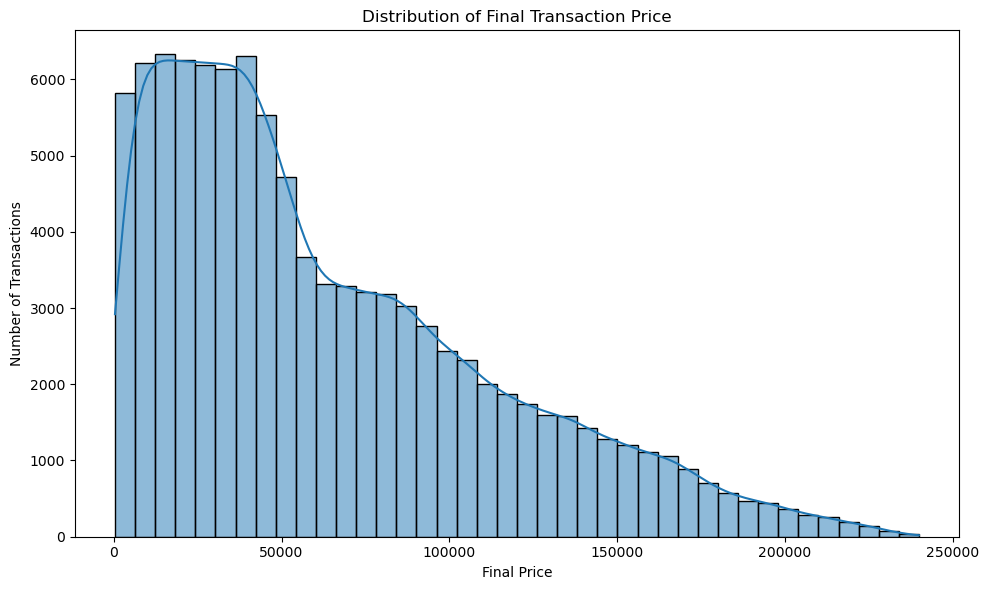

In [51]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df_eda,
    x='final_price',
    bins=40,
    kde=True
)

plt.title('Distribution of Final Transaction Price')
plt.xlabel('Final Price')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

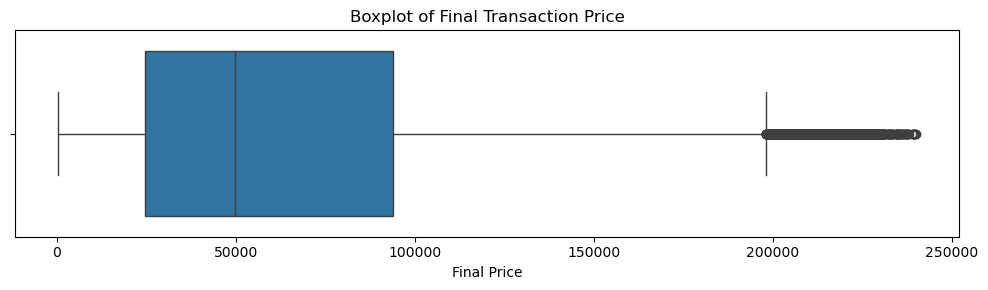

In [52]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df_eda,
    x='final_price'
)

plt.title('Boxplot of Final Transaction Price')
plt.xlabel('Final Price')
plt.tight_layout()
plt.show()

### Final Price — Observation

The final transaction price exhibits a pronounced right-skewed distribution.
Most transactions are concentrated in the lower-to-middle price range, while
the frequency of transactions decreases progressively toward higher values.

The mean final price (₹64,165.72) is considerably higher than the median
(₹49,752.39), and the skewness value of 0.93 confirms positive asymmetry.

The boxplot shows numerous observations beyond the upper whisker, indicating
the presence of extreme high-value transactions.

### Interpretation

The distribution suggests that transaction values are concentrated around
lower and medium price levels, while a smaller number of high-value purchases
extend the upper tail and increase the average transaction value.

These extreme observations should not automatically be considered erroneous.
They will be examined formally using the IQR and Z-score methods during the
dedicated outlier analysis stage.

### Advanced View: Log-Transformed Final Price

Because the final price distribution is strongly right-skewed, a logarithmic
transformation is used to provide a clearer view of the distribution across
different price magnitudes.

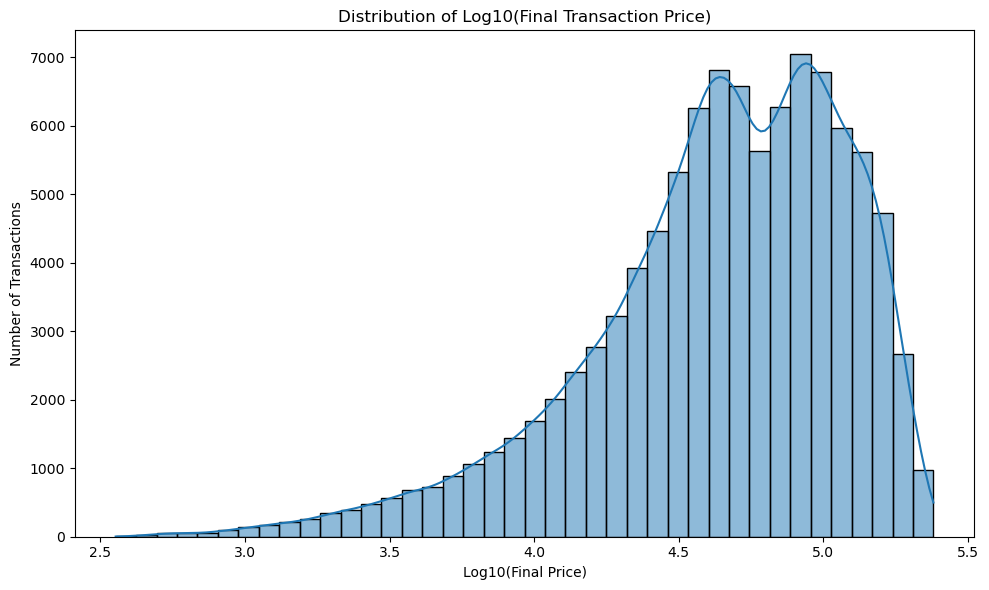

In [53]:
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log10(df_eda['final_price']),
    bins=40,
    kde=True
)

plt.title('Distribution of Log10(Final Transaction Price)')
plt.xlabel('Log10(Final Price)')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

### Log-Transformed Final Price — Observation

The logarithmic transformation compresses the wide range of final transaction
prices and makes the distribution of lower- and higher-value transactions easier
to compare visually.

Compared with the original distribution, the transformed view reduces the
influence of the extreme upper tail and provides a clearer representation of
the main concentration of transaction values.

### Interpretation

The log-transformed visualization confirms that the original right-skewness is
primarily associated with the wide range of transaction values and the presence
of relatively high-value purchases. The transformation is used only as an
analytical visualization technique; the original `final_price` values remain
unchanged in the dataset.

## 3.7 Delivery Days

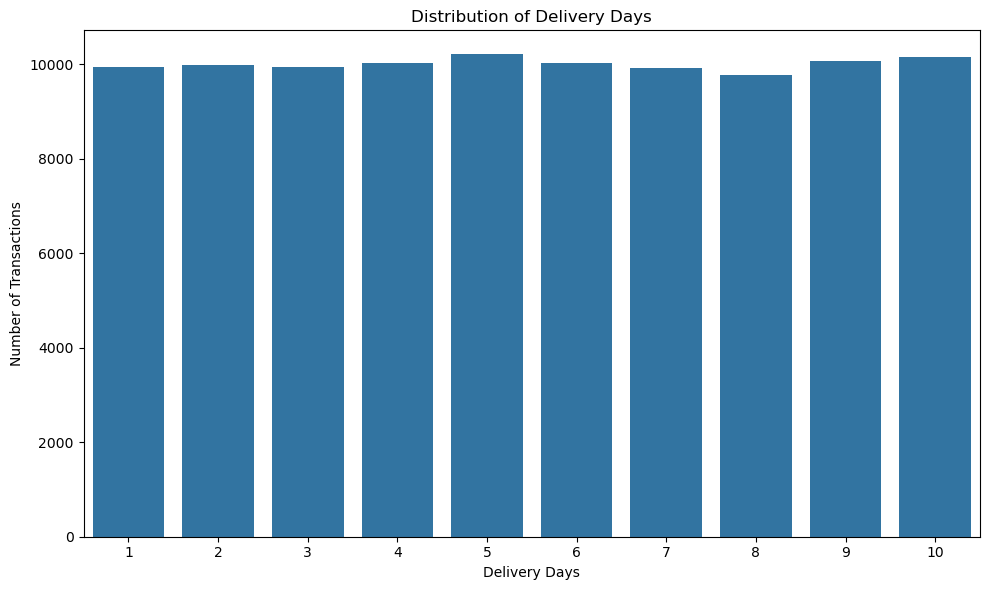

In [54]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_eda,
    x='delivery_days'
)

plt.title('Distribution of Delivery Days')
plt.xlabel('Delivery Days')
plt.ylabel('Number of Transactions')
plt.tight_layout()
plt.show()

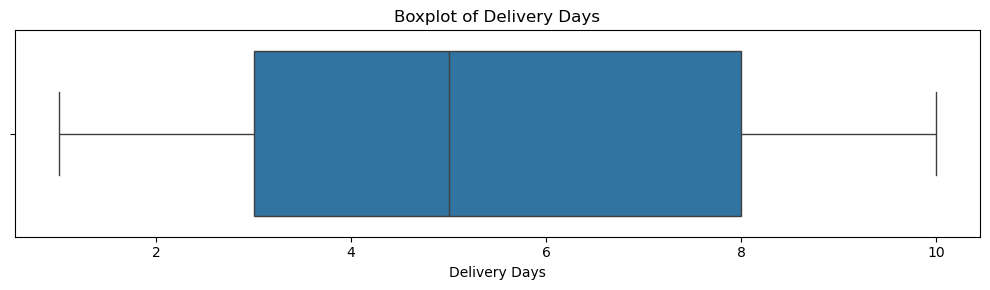

In [55]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    data=df_eda,
    x='delivery_days'
)

plt.title('Boxplot of Delivery Days')
plt.xlabel('Delivery Days')
plt.tight_layout()
plt.show()

### Delivery Days — Observation

Delivery times range from 1 to 10 days and are distributed relatively evenly
across the available values. No single delivery duration accounts for a
substantially larger share of transactions.

The mean delivery time is 5.51 days, while the median is 5 days. The
approximately zero skewness indicates a balanced distribution with little
asymmetry.

The boxplot shows a spread from 1 to 10 days without prominent observations
outside the whiskers.

### Interpretation

The dataset represents a relatively balanced distribution of delivery
durations rather than being heavily concentrated around very short or very long
delivery times. No prominent extreme observations are visible in the basic
boxplot, although formal outlier detection will be performed separately.

## 3.8 Comparative Skewness Analysis

Skewness is compared across the numerical variables to identify variables with
substantial distributional asymmetry. This provides a compact comparison of the
individual distribution analyses performed above.

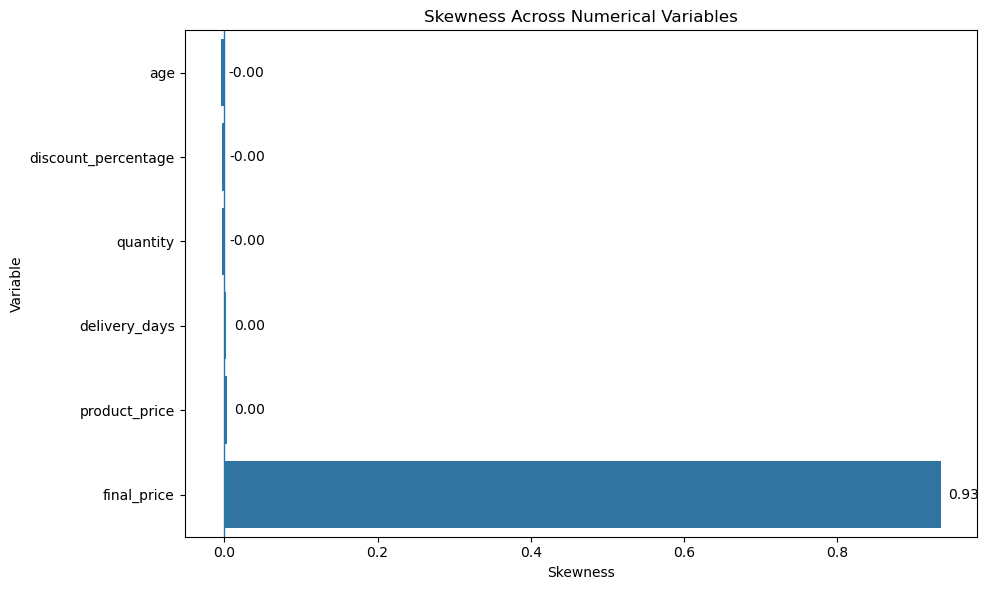

In [57]:
plt.figure(figsize=(10, 6))

skewness_values = numerical_stats['Skewness'].sort_values()

ax = sns.barplot(
    x=skewness_values.values,
    y=skewness_values.index
)

for i, value in enumerate(skewness_values.values):
    ax.text(
        value + 0.01,
        i,
        f'{value:.2f}',
        va='center'
    )

plt.axvline(0, linewidth=1)
plt.title('Skewness Across Numerical Variables')
plt.xlabel('Skewness')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

### Comparative Skewness — Observation

The comparative skewness analysis shows that most numerical variables have
skewness values close to zero, indicating approximately symmetric distributions.

In contrast, `final_price` has a skewness of 0.93, making it the only numerical
variable with noticeable positive asymmetry.

### Interpretation

The distribution of most numerical variables is relatively balanced, whereas
`final_price` has a pronounced right-skewed distribution caused by a smaller
number of higher-value transactions extending the upper tail.

This makes `final_price` the primary numerical variable requiring further
attention during outlier and distribution analysis.